# Simple Post-Shot xG

This notebook implements a simple post-shot xg with python3.10. 

For reference, read [this blog](https://thesporting.blog/blog/post-shot-expected-goals-what-is-it-and-why-does-it-matter),
[this other blog](https://statsbomb.com/articles/soccer/a-new-way-to-measure-keepers-shot-stopping-post-shot-expected-goals/),
and [this other super relevant blog](https://statsbomb.com/articles/soccer/upgrading-expected-goals/).

- Super naive xG, with angle and distance as features
- Super naive post-shot-xG, adding GK position as feature
- Less naive post-shot-xG, adding gk angle occlusion
- Even less post-shot-xg, adding all the opposition occlusion

Angle and distance can be derived from regular event data. GK position and available angle we use agent imputer data.

Agent imputer is a src model that predicts players position based on event data. Therefore, the data can have noise. The goal of the project is to check if this noise is usable or not.

## Imports and data load

In [8]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import json
import matplotlib.pyplot as plt

In [9]:
data = pd.read_csv('shots_agent_imputer.csv')

In [10]:
data = data.loc[data['type_primary'] == 'shot']
data = data.loc[data['shot_ontarget'] == True]

In [11]:
data["player_data"] = data["player_data"].map(json.loads)

## xG

This sections makes a notebook that uses distance to goal and angle to goal

In [14]:
GOAL_X = 105
GOAL_Y = 34
GOAL_WIDTH = 7.32

In [15]:
# get the distance to the goal
data["dist_to_goal"] = np.sqrt(
    (data["event_start_x"] - GOAL_X) ** 2 + (data["event_start_y"] - GOAL_Y) ** 2
)

In [16]:
data["C"] = data["event_start_y"].apply(lambda cell: abs(cell - GOAL_Y) * GOAL_Y*2/GOAL_X)

data["angle_to_goal"] = np.where(
    np.arctan(GOAL_WIDTH * data["event_start_x"] / (data["event_start_x"]**2 + data["C"]**2 - (GOAL_WIDTH/2)**2)) > 0,
    np.arctan(GOAL_WIDTH * data["event_start_x"] /(data["event_start_x"]**2 + data["C"]**2 - (GOAL_WIDTH/2)**2)),
    np.arctan(GOAL_WIDTH * data["event_start_x"] /(data["event_start_x"]**2 + data["C"]**2 - (GOAL_WIDTH/2)**2)) + np.pi
)
data["angle_to_goal"] = np.degrees(data["angle_to_goal"])

In [17]:
# normalize
# make dist go from 0 to 1
data["dist_to_goal_norm"] = (
    data["dist_to_goal"] - data["dist_to_goal"].min()
) / (
    data["dist_to_goal"].max() - data["dist_to_goal"].min()
)

# make angle go from 0 to 1
data["angle_to_goal_norm"] = data["angle_to_goal"] / np.pi

In [18]:
# filter shots only
shot = data[data["type_primary"] == "shot"]

In [19]:
# split data into train and test
x_train_xg, x_test_xg, y_train_xg, y_test_xg = train_test_split(
    shot[["dist_to_goal_norm", "pass_accurate"]],
    shot["shot_isgoal"],
    test_size=0.2,
    random_state=42,
)

In [20]:
# train the model checking for overfitting
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)

model.fit(
    x_train_xg,
    y_train_xg,
    eval_set=[(x_train_xg, y_train_xg), (x_test_xg, y_test_xg)],
    verbose=True,
)

[0]	validation_0-logloss:0.61415	validation_1-logloss:0.61046
[1]	validation_0-logloss:0.60891	validation_1-logloss:0.60513
[2]	validation_0-logloss:0.60417	validation_1-logloss:0.60025
[3]	validation_0-logloss:0.59980	validation_1-logloss:0.59593
[4]	validation_0-logloss:0.59592	validation_1-logloss:0.59200
[5]	validation_0-logloss:0.59240	validation_1-logloss:0.58841
[6]	validation_0-logloss:0.58923	validation_1-logloss:0.58518
[7]	validation_0-logloss:0.58643	validation_1-logloss:0.58237
[8]	validation_0-logloss:0.58394	validation_1-logloss:0.57996
[9]	validation_0-logloss:0.58155	validation_1-logloss:0.57762
[10]	validation_0-logloss:0.57943	validation_1-logloss:0.57559
[11]	validation_0-logloss:0.57747	validation_1-logloss:0.57363
[12]	validation_0-logloss:0.57566	validation_1-logloss:0.57183
[13]	validation_0-logloss:0.57406	validation_1-logloss:0.57019
[14]	validation_0-logloss:0.57259	validation_1-logloss:0.56873
[15]	validation_0-logloss:0.57116	validation_1-logloss:0.56737
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

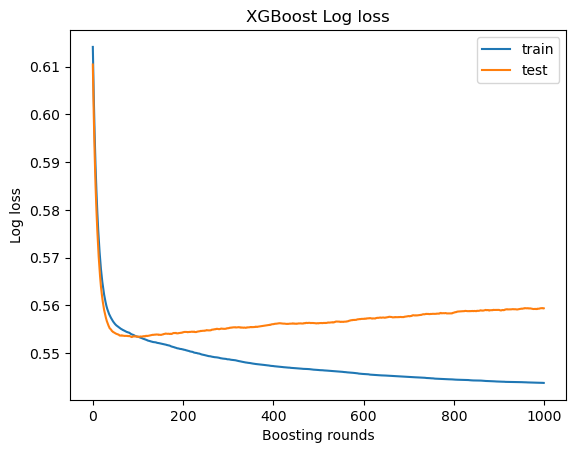

In [21]:
results = model.evals_result()
# plot the results
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="test")
plt.xlabel("Boosting rounds")
plt.ylabel("Log loss")
plt.legend()
plt.title("XGBoost Log loss")
plt.show()

In [22]:
# make predictions
y_pred = model.predict(x_test_xg)
y_pred_proba = model.predict_proba(x_test_xg)[:, 1]


In [23]:
def test_model(y_test, y_pred, y_pred_proba):

    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error: {mse}")
    
    # Calculate ROC AUC
    roc_auc = roc_auc_score(np.array(y_test).astype(int), np.array(y_pred_proba))
    print(f"ROC AUC: {roc_auc}")

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(np.array(y_test).astype(int), y_pred_proba)
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()

Mean Squared Error: 0.28017763423496167
ROC AUC: 0.6976150378615328


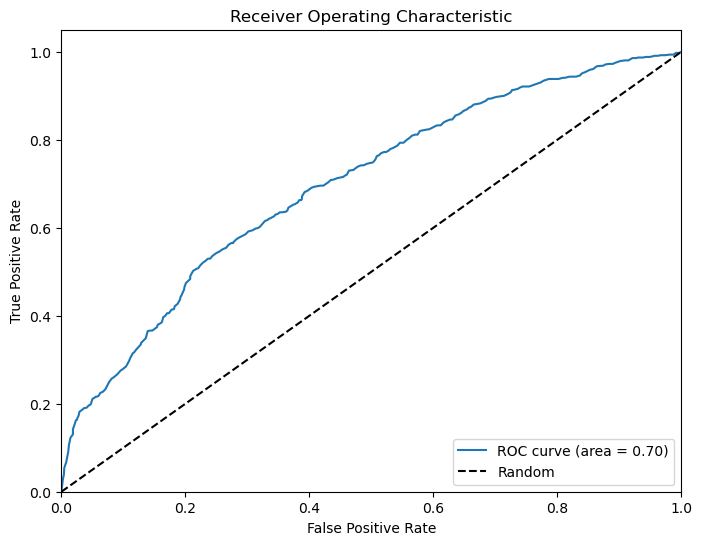

In [24]:
test_model(y_test_xg, y_pred, y_pred_proba)

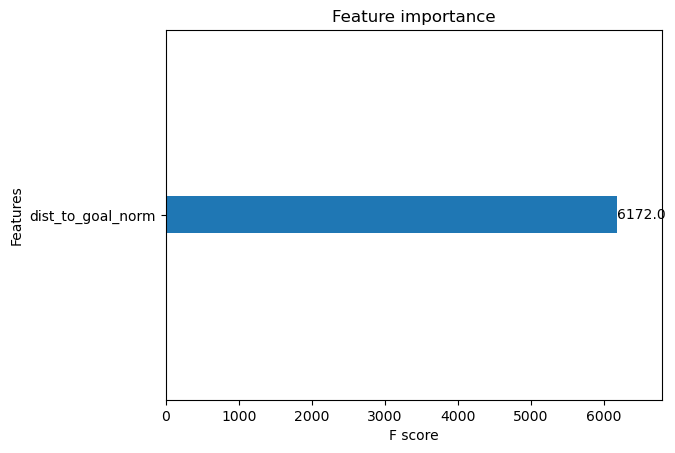

In [25]:
# feature importance
xgb.plot_importance(
    model,
    importance_type="weight",
    title="Feature importance",
    xlabel="F score",
    ylabel="Features",
    grid=False,
)
plt.show()

In [26]:
x_train_xg, x_test_xg, y_train_xg, y_test_xg = train_test_split(
    shot[["dist_to_goal_norm", "angle_to_goal_norm","groundduel_keptpossession"]],
    shot["shot_isgoal"],
    test_size=0.2,
    random_state=42,
)

In [27]:
model = xgb.XGBClassifier(
    n_estimators=1000,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42,
)

model.fit(
    x_train_xg,
    y_train_xg,
    eval_set=[(x_train_xg, y_train_xg), (x_test_xg, y_test_xg)],
    verbose=True,
)

[0]	validation_0-logloss:0.61389	validation_1-logloss:0.61040
[1]	validation_0-logloss:0.60840	validation_1-logloss:0.60489
[2]	validation_0-logloss:0.60330	validation_1-logloss:0.59969
[3]	validation_0-logloss:0.59860	validation_1-logloss:0.59516
[4]	validation_0-logloss:0.59449	validation_1-logloss:0.59117
[5]	validation_0-logloss:0.59089	validation_1-logloss:0.58755
[6]	validation_0-logloss:0.58753	validation_1-logloss:0.58417
[7]	validation_0-logloss:0.58445	validation_1-logloss:0.58125
[8]	validation_0-logloss:0.58180	validation_1-logloss:0.57864
[9]	validation_0-logloss:0.57932	validation_1-logloss:0.57614
[10]	validation_0-logloss:0.57705	validation_1-logloss:0.57388
[11]	validation_0-logloss:0.57483	validation_1-logloss:0.57177
[12]	validation_0-logloss:0.57285	validation_1-logloss:0.56979
[13]	validation_0-logloss:0.57096	validation_1-logloss:0.56795
[14]	validation_0-logloss:0.56937	validation_1-logloss:0.56642
[15]	validation_0-logloss:0.56778	validation_1-logloss:0.56490
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=1000,
              n_jobs=None, num_parallel_tree=None, ...)

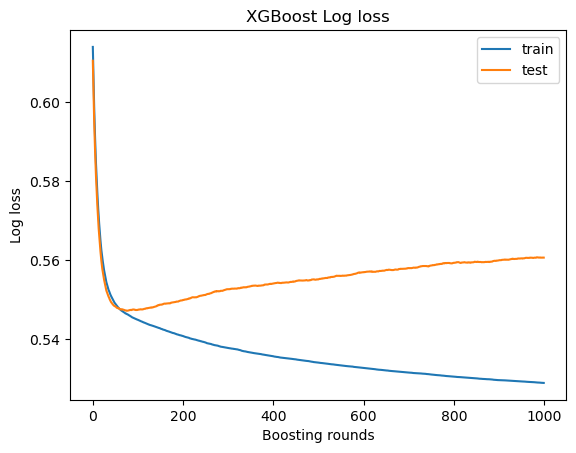

In [28]:
results = model.evals_result()
# plot the results
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="test")
plt.xlabel("Boosting rounds")
plt.ylabel("Log loss")
plt.legend()
plt.title("XGBoost Log loss")
plt.show()

In [29]:
def test_model(y_test, y_pred, y_pred_proba):

    mse = mean_squared_error(y_test, y_pred)
    print(f"Mean Squared Error: {mse}")
    
    # Calculate ROC AUC
    roc_auc = roc_auc_score(np.array(y_test).astype(int), np.array(y_pred_proba))
    print(f"ROC AUC: {roc_auc}")

    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(np.array(y_test).astype(int), y_pred_proba)
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, label=f"ROC curve (area = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc='lower right')
    plt.show()

Mean Squared Error: 0.28017763423496167
ROC AUC: 0.6976150378615328


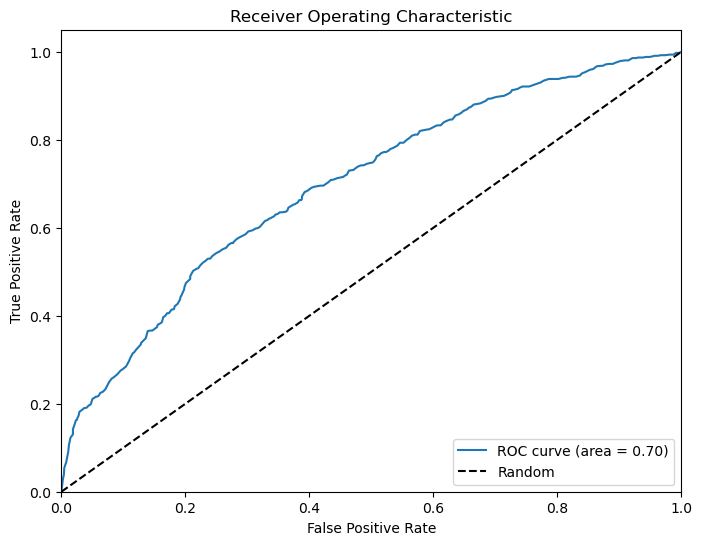

In [30]:
test_model(y_test_xg, y_pred, y_pred_proba)

## Naive post-shot-xG: adding keeper position

Now we make xg but adding information on keeper location

In [33]:
psxg_data = data[(data["shot_ontarget"])&(data["type_primary"] == "shot")]

In [34]:
def get_gk_xy(players):
    for p in players:
        if p["player_position"] == "GK" and p["in_possession"] == False:
            return 105-p["x"], p["y"]
    return None, None

# psxg_data[["gk_x", "gk_y"]] = pd.DataFrame.from_records(
#     psxg_data["player_data"].map(get_gk_xy)
# )
psxg_data["gk_x"] = psxg_data["player_data"].map(lambda x: get_gk_xy(x)[0])
psxg_data["gk_y"] = psxg_data["player_data"].map(lambda x: get_gk_xy(x)[1])

In [35]:
psxg_data[psxg_data["gk_x"].isna()].shape

(6, 201)

In [36]:
psxg_data = psxg_data[~psxg_data["gk_x"].isna()]
psxg_data.shape

(12376, 201)

In [37]:
# normalize gk x
psxg_data["gk_x_norm"] = psxg_data["gk_x"] / 105
psxg_data["gk_y_norm"] = psxg_data["gk_y"] / 68

In [38]:
# split data into train and test
x_train_xg_gk, x_test_xg_gk, y_train_xg_gk, y_test_xg_gk = train_test_split(
    psxg_data[[
        "dist_to_goal_norm",
        "angle_to_goal_norm",
        "gk_x_norm",
        "gk_y_norm",
    ]],
    psxg_data["shot_isgoal"],
    test_size=0.2,
    random_state=42,
)

In [39]:
# train the model checking for overfitting
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05
    ,
    subsample=0.8,
    colsample_bytree=0.75,
    random_state=42,
)
model.fit(
    x_train_xg_gk,
    y_train_xg_gk,
    eval_set=[(x_train_xg_gk, y_train_xg_gk), (x_test_xg_gk, y_test_xg_gk)],
    verbose=True,
)

[0]	validation_0-logloss:0.61360	validation_1-logloss:0.61056
[1]	validation_0-logloss:0.60829	validation_1-logloss:0.60469
[2]	validation_0-logloss:0.60349	validation_1-logloss:0.59964
[3]	validation_0-logloss:0.59908	validation_1-logloss:0.59486
[4]	validation_0-logloss:0.59502	validation_1-logloss:0.59058
[5]	validation_0-logloss:0.59153	validation_1-logloss:0.58697
[6]	validation_0-logloss:0.58822	validation_1-logloss:0.58366
[7]	validation_0-logloss:0.58512	validation_1-logloss:0.58041
[8]	validation_0-logloss:0.58234	validation_1-logloss:0.57771
[9]	validation_0-logloss:0.57968	validation_1-logloss:0.57497
[10]	validation_0-logloss:0.57734	validation_1-logloss:0.57256
[11]	validation_0-logloss:0.57527	validation_1-logloss:0.57058
[12]	validation_0-logloss:0.57324	validation_1-logloss:0.56843
[13]	validation_0-logloss:0.57216	validation_1-logloss:0.56734
[14]	validation_0-logloss:0.57051	validation_1-logloss:0.56573
[15]	validation_0-logloss:0.56896	validation_1-logloss:0.56415
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.75, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

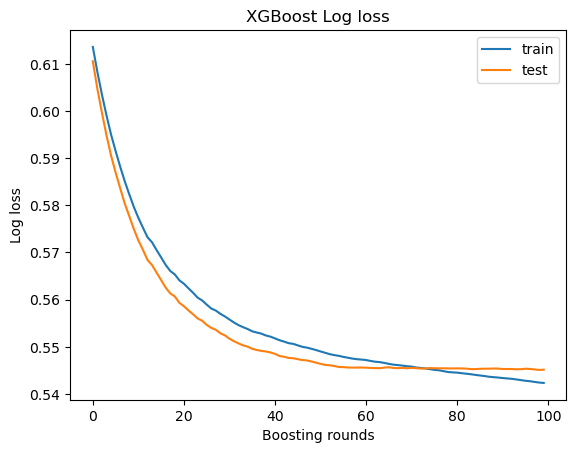

In [40]:
results = model.evals_result()
# plot the results
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="test")
plt.xlabel("Boosting rounds")
plt.ylabel("Log loss")
plt.legend()
plt.title("XGBoost Log loss")
plt.show()

Mean Squared Error: 0.26777059773828754
ROC AUC: 0.7170092290717677


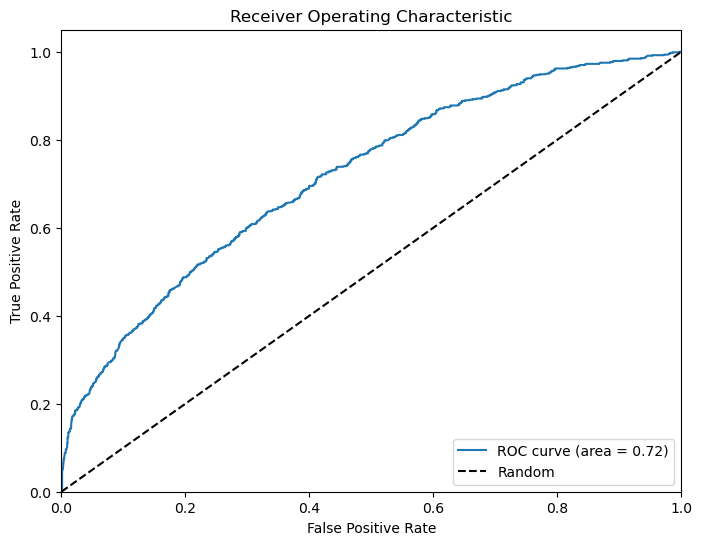

In [41]:
y_pred = model.predict(x_test_xg_gk)
y_pred_proba = model.predict_proba(x_test_xg_gk)[:, 1]
test_model(y_test_xg_gk, y_pred, y_pred_proba)

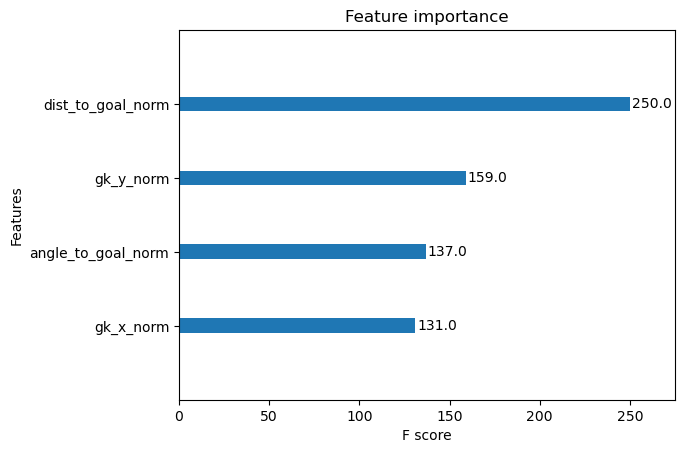

In [42]:
# feature importance
xgb.plot_importance(
    model,
    importance_type="weight",
    title="Feature importance",
    xlabel="F score",
    ylabel="Features",
    grid=False,
)
plt.show()

## Naive post-shot-xG: keeper occlusion

Now we add a feature related to the how much does the keeper occludes the angle of view

In [45]:
KEEPER_WIDTH = 1.5

# goal posts coordinates:
post_left  = np.array([GOAL_Y/2 - GOAL_WIDTH/2, 0.0])
post_right = np.array([GOAL_Y/2 + GOAL_WIDTH/2, 0.0])

# unit‐vector along the goal‐line:
gdir = (post_right - post_left)
gdir = gdir / np.linalg.norm(gdir)

# perpendicular direction (points into the field):
perp = np.array([-gdir[1], gdir[0]])  # rotates gdir by +90°

In [46]:
shots_on_target = np.stack([psxg_data['event_start_x'].values, psxg_data['event_start_y'].values], axis=1)

keepers = np.stack([psxg_data['gk_x'].values, psxg_data['gk_y'].values], axis=1)

In [47]:
# Raw goal angle at each shot

# vectors from shot → each post
L = post_left[None,:]  - shots_on_target
R = post_right[None,:] - shots_on_target

# dot products and norms
dot_LR = np.einsum('ij,ij->i', L, R)
norm_L = np.linalg.norm(L, axis=1)
norm_R = np.linalg.norm(R, axis=1)

# clamp for numerical safety
cos_goal = np.clip(dot_LR / (norm_L * norm_R), -1.0, 1.0)
theta_goal = np.arccos(cos_goal)    # radians, shape (N,)

In [48]:
# Keeper occlusion angle
K1 = keepers + perp[None,:] * (KEEPER_WIDTH/2)
K2 = keepers - perp[None,:] * (KEEPER_WIDTH/2)

C = K1 - shots_on_target
D = K2 - shots_on_target

dot_CD = np.einsum('ij,ij->i', C, D)
norm_C  = np.linalg.norm(C, axis=1)
norm_D  = np.linalg.norm(D, axis=1)

cos_keeper = np.clip(dot_CD / (norm_C * norm_D), -1.0, 1.0)
theta_keeper = np.arccos(cos_keeper)   # radians, shape (N,)

In [49]:
# Visible angle
visible_radians = theta_goal - theta_keeper
visible_radians = np.maximum(visible_radians, 0.0)  # no negative angles
visible_degrees = np.degrees(visible_radians)

# attach it back to your DataFrame
psxg_data['visible_angle_rad'] = visible_radians
psxg_data['visible_angle_deg'] = visible_degrees

In [50]:
# norm visible angle
psxg_data["visible_angle_rad_norm"] = (
    psxg_data["visible_angle_rad"] - psxg_data["visible_angle_rad"].min()
) / (
    psxg_data["visible_angle_rad"].max() - psxg_data["visible_angle_rad"].min()
)

In [51]:
# split data into train and test
x_train_gk_angle, x_test_gk_angle, y_train_gk_angle, y_test_gk_angle = train_test_split(
    psxg_data[[
        "dist_to_goal_norm",
        "angle_to_goal_norm",
        "gk_x_norm",
        "gk_y_norm",
        "visible_angle_rad_norm",
    ]],
    psxg_data["shot_isgoal"],
    test_size=0.2,
    random_state=42,
)

In [52]:
# train
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
model.fit(
    x_train_gk_angle,
    y_train_gk_angle,
    eval_set=[(x_train_gk_angle, y_train_gk_angle), (x_test_gk_angle, y_test_gk_angle)],
    verbose=True,
)

[0]	validation_0-logloss:0.61358	validation_1-logloss:0.61060
[1]	validation_0-logloss:0.60829	validation_1-logloss:0.60477
[2]	validation_0-logloss:0.60335	validation_1-logloss:0.59955
[3]	validation_0-logloss:0.59897	validation_1-logloss:0.59479
[4]	validation_0-logloss:0.59490	validation_1-logloss:0.59051
[5]	validation_0-logloss:0.59143	validation_1-logloss:0.58685
[6]	validation_0-logloss:0.58910	validation_1-logloss:0.58447
[7]	validation_0-logloss:0.58590	validation_1-logloss:0.58114
[8]	validation_0-logloss:0.58303	validation_1-logloss:0.57834
[9]	validation_0-logloss:0.58051	validation_1-logloss:0.57579
[10]	validation_0-logloss:0.57799	validation_1-logloss:0.57305
[11]	validation_0-logloss:0.57579	validation_1-logloss:0.57087
[12]	validation_0-logloss:0.57383	validation_1-logloss:0.56882
[13]	validation_0-logloss:0.57204	validation_1-logloss:0.56704
[14]	validation_0-logloss:0.57080	validation_1-logloss:0.56589
[15]	validation_0-logloss:0.56922	validation_1-logloss:0.56443
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

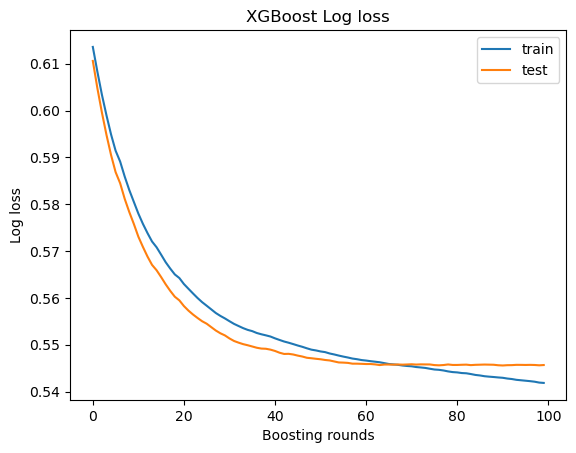

In [53]:
results = model.evals_result()
# plot the results
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="test")
plt.xlabel("Boosting rounds")
plt.ylabel("Log loss")
plt.legend()
plt.title("XGBoost Log loss")
plt.show()

Mean Squared Error: 0.26777059773828754
ROC AUC: 0.7161958907835708


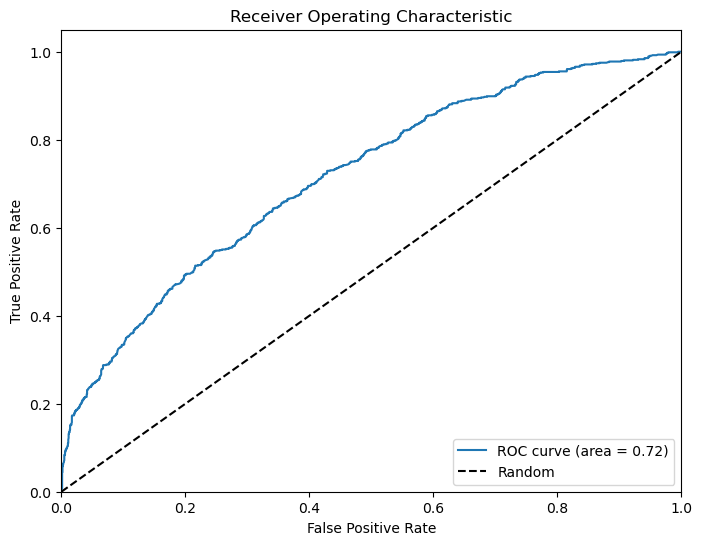

In [54]:
y_pred = model.predict(x_test_gk_angle)
y_pred_proba = model.predict_proba(x_test_gk_angle)[:, 1]
test_model(y_test_gk_angle, y_pred, y_pred_proba)

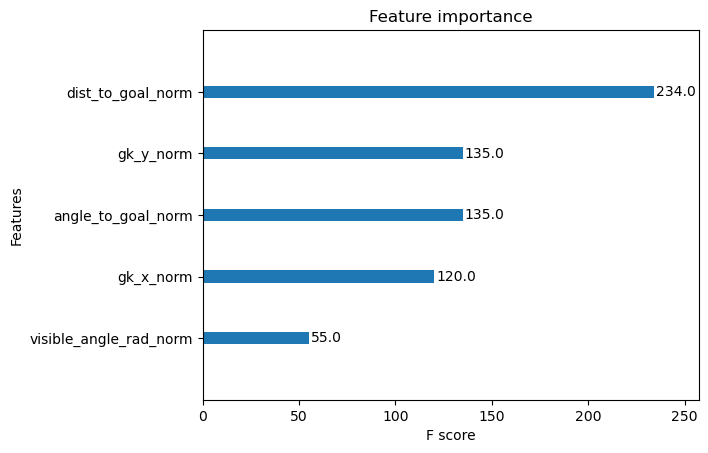

In [55]:
# feature importance
xgb.plot_importance(
    model,
    importance_type="weight",
    title="Feature importance",
    xlabel="F score",
    ylabel="Features",
    grid=False,
)
plt.show()

## Naive post-shot-xg: opposition occlusion

Finally, we add a feature to see how much all defending player occlude the shto

In [58]:
PLAYER_WIDTH = 0.8

In [59]:
exploded = psxg_data[
    ["player_data", "event_start_x", "event_start_y", "angle_to_goal"]
].explode("player_data").dropna(subset=["player_data"])

mask = exploded["player_data"].map(lambda p: not p["in_possession"])
exploded = exploded[mask].copy()

# pull blocker coords
exploded["bx"] = exploded["player_data"].map(lambda p: 105 - p["x"]) # flip x for not in possession
exploded["by"] = exploded["player_data"].map(lambda p: p["y"])

# prject player's 0.6 m body onto the goal-line
S = np.stack([exploded["event_start_x"], exploded["event_start_y"]], axis=1)
K = np.stack([exploded["bx"], exploded["by"]], axis=1)

half_w = PLAYER_WIDTH/2
# endpoints of the blocker segment (still at by)
K1 = K + np.array([-half_w, 0.0])
K2 = K + np.array([ half_w, 0.0])

# line S→K1 intersects y=0 at t1:  Sy + t1*(K1y-Sy)=0  ⇒  t1 = -Sy/(K1y-Sy)
t1 = -S[:,1] / (K1[:,1] - S[:,1])
t2 = -S[:,1] / (K2[:,1] - S[:,1])

# intersection points on goal-line
P1 = S + (K1 - S) * t1[:,None]
P2 = S + (K2 - S) * t2[:,None]

# compute occlusion angle for each blocker
v1 = P1 - S
v2 = P2 - S

dot12 = np.einsum("ij,ij->i", v1, v2)
n1 = np.linalg.norm(v1, axis=1)
n2 = np.linalg.norm(v2, axis=1)
cos_occl = np.clip(dot12 / (n1 * n2), -1.0, 1.0)
theta_occl = np.arccos(cos_occl)   # radians

# sum per shot and subtract from raw goal angle
occl_sum = pd.Series(theta_occl, index=exploded.index).groupby(level=0).sum()

psxg_data["total_occlusion_rad"] = occl_sum.reindex(psxg_data.index).fillna(0.0)

psxg_data["visible_with_blockers_rad"] = (
    psxg_data["angle_to_goal"] - psxg_data["total_occlusion_rad"]
).clip(lower=0.0)

psxg_data["visible_with_blockers_deg"] = np.degrees(psxg_data["visible_with_blockers_rad"])

In [60]:
psxg_data["visible_with_blockers_deg_norm"] = (
    psxg_data["visible_with_blockers_deg"] - psxg_data["visible_with_blockers_deg"].min()
) / (
    psxg_data["visible_with_blockers_deg"].max() - psxg_data["visible_with_blockers_deg"].min()
)

In [61]:
# Train a new XGBoost classifier using the keeper occlusion features
x_train_gk_angle_xg, x_test_gk_angle_xg, y_train_gk_angle, y_test_gk_angle = train_test_split(
    psxg_data[[
        "dist_to_goal_norm",
        "angle_to_goal_norm",
        "gk_x_norm",
        "gk_y_norm",
        "visible_with_blockers_deg_norm",
    ]],
    psxg_data["shot_isgoal"],
    test_size=0.2,
    random_state=42,
    stratify=psxg_data[psxg_data["type_primary"] == "shot"]["shot_isgoal"],
)

model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(
    x_train_gk_angle_xg,
    y_train_gk_angle,
    eval_set=[(x_train_gk_angle_xg, y_train_gk_angle), (x_test_gk_angle_xg, y_test_gk_angle)],
    verbose=True,
)

[0]	validation_0-logloss:0.61301	validation_1-logloss:0.61298
[1]	validation_0-logloss:0.60759	validation_1-logloss:0.60765
[2]	validation_0-logloss:0.60255	validation_1-logloss:0.60268
[3]	validation_0-logloss:0.59806	validation_1-logloss:0.59817
[4]	validation_0-logloss:0.59396	validation_1-logloss:0.59427
[5]	validation_0-logloss:0.59045	validation_1-logloss:0.59090
[6]	validation_0-logloss:0.58806	validation_1-logloss:0.58855
[7]	validation_0-logloss:0.58488	validation_1-logloss:0.58519
[8]	validation_0-logloss:0.58210	validation_1-logloss:0.58259
[9]	validation_0-logloss:0.57953	validation_1-logloss:0.58022
[10]	validation_0-logloss:0.57718	validation_1-logloss:0.57799
[11]	validation_0-logloss:0.57506	validation_1-logloss:0.57588
[12]	validation_0-logloss:0.57309	validation_1-logloss:0.57403
[13]	validation_0-logloss:0.57127	validation_1-logloss:0.57243
[14]	validation_0-logloss:0.57010	validation_1-logloss:0.57146
[15]	validation_0-logloss:0.56839	validation_1-logloss:0.56993
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

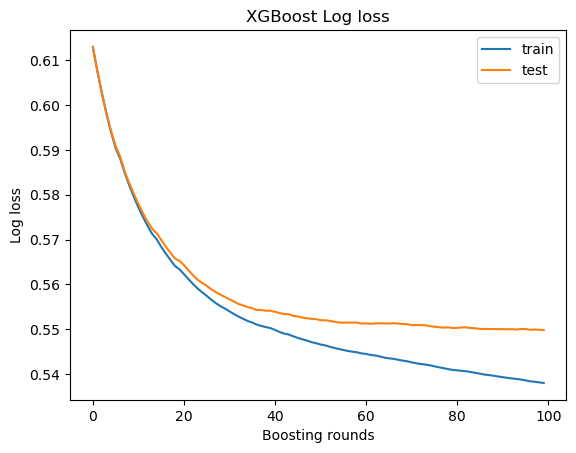

In [62]:
results = model.evals_result()
# plot the results
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="test")
plt.xlabel("Boosting rounds")
plt.ylabel("Log loss")
plt.legend()
plt.title("XGBoost Log loss")
plt.show()

Mean Squared Error: 0.2710016155088853
ROC AUC: 0.7224941505321547


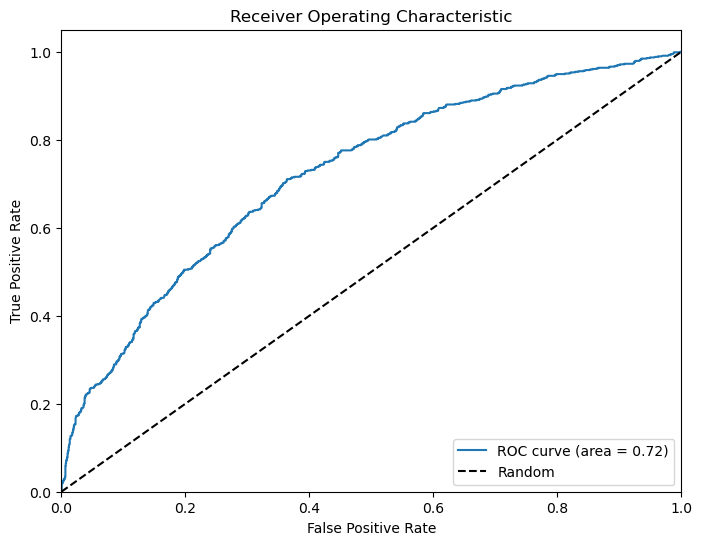

In [63]:
# Make predictions and evaluate the model using the test_model function defined earlier
y_pred = model.predict(x_test_gk_angle_xg)
y_pred_proba = model.predict_proba(x_test_gk_angle_xg)[:, 1]
test_model(y_test_gk_angle, y_pred, y_pred_proba)

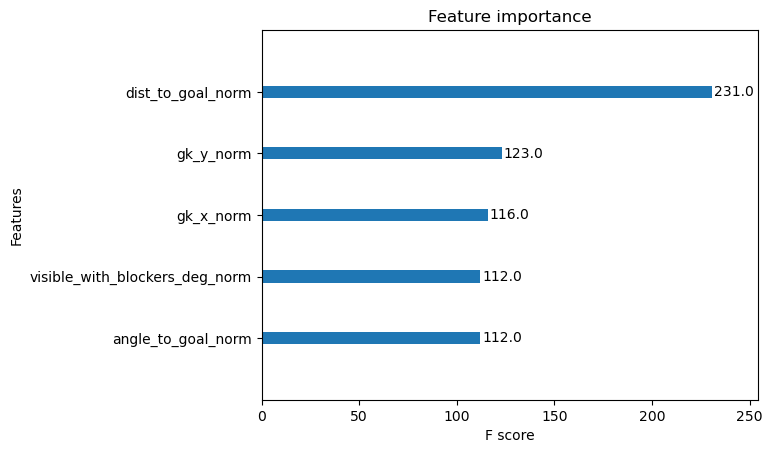

In [64]:
# feature importance
xgb.plot_importance(
    model,
    importance_type="weight",
    title="Feature importance",
    xlabel="F score",
    ylabel="Features",
    grid=False,
)
plt.show()

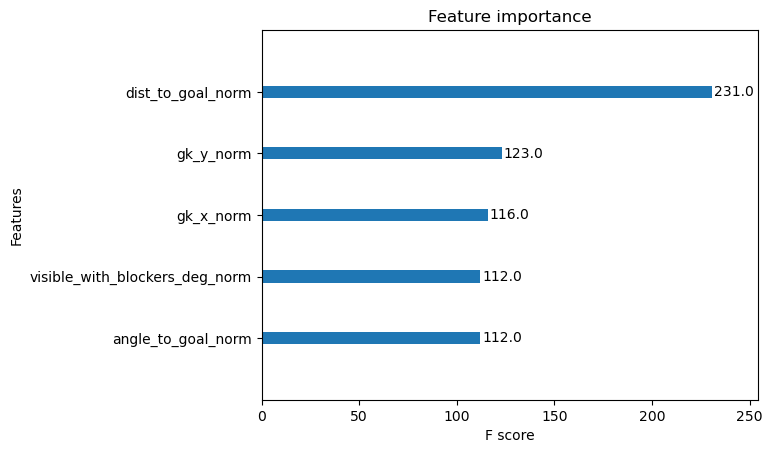

In [65]:
xgb.plot_importance(
    model,
    importance_type="weight",
    title="Feature importance",
    xlabel="F score",
    ylabel="Features",
    grid=False,
)
plt.show()

In [66]:
psxg_data["shot_goalzone"] = psxg_data["shot_goalzone"].astype("category")
psxg_data = pd.get_dummies(psxg_data, columns=["shot_goalzone"], prefix="goalzone")

psxg_data["shot_bodypart"] = psxg_data["shot_bodypart"].astype("category")
psxg_data = pd.get_dummies(psxg_data, columns=["shot_bodypart"], prefix="bodypart")

psxg_data["phase_of_play_name"] = psxg_data["phase_of_play_name"].astype("category")
psxg_data = pd.get_dummies(psxg_data, columns=["phase_of_play_name"], prefix="phase_of_play_name")

psxg_data['shot_ontarget'] = psxg_data['shot_ontarget'].astype(int)

In [67]:
x_train_xg_gk, x_test_xg_gk, y_train_xg_gk, y_test_xg_gk = train_test_split(
    psxg_data[[
        "dist_to_goal_norm",
        "angle_to_goal_norm",
        "gk_x_norm",
        "gk_y_norm",
        "visible_with_blockers_deg_norm",
        "src_shot_xg",
        "shot_ontarget",
        'goalzone_bc', 'goalzone_gb',
       'goalzone_gbr', 'goalzone_gc', 'goalzone_gl', 'goalzone_glb',
       'goalzone_gr', 'goalzone_gt', 'goalzone_gtl', 'goalzone_gtr',
       'goalzone_obr', 'goalzone_olb',
       'bodypart_head_or_other', 'bodypart_left_foot', 'bodypart_right_foot',
       'phase_of_play_name_Contested','phase_of_play_name_Controlled','phase_of_play_name_Set Piece','phase_of_play_name_Transition'
        
    ]],
    psxg_data["shot_isgoal"],
    test_size=0.2,
    random_state=42,
)

In [68]:
model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)

model.fit(
    x_train_xg_gk,
    y_train_xg_gk,
    eval_set=[(x_train_xg_gk, y_train_xg_gk),(x_test_xg_gk, y_test_xg_gk)],
    verbose=True,
)

[0]	validation_0-logloss:0.61296	validation_1-logloss:0.60983
[1]	validation_0-logloss:0.60570	validation_1-logloss:0.60203
[2]	validation_0-logloss:0.59918	validation_1-logloss:0.59500
[3]	validation_0-logloss:0.59278	validation_1-logloss:0.58800
[4]	validation_0-logloss:0.58691	validation_1-logloss:0.58156
[5]	validation_0-logloss:0.58251	validation_1-logloss:0.57715
[6]	validation_0-logloss:0.57725	validation_1-logloss:0.57129
[7]	validation_0-logloss:0.57237	validation_1-logloss:0.56587
[8]	validation_0-logloss:0.56780	validation_1-logloss:0.56145
[9]	validation_0-logloss:0.56308	validation_1-logloss:0.55712
[10]	validation_0-logloss:0.55928	validation_1-logloss:0.55329
[11]	validation_0-logloss:0.55563	validation_1-logloss:0.54980
[12]	validation_0-logloss:0.55242	validation_1-logloss:0.54625
[13]	validation_0-logloss:0.54983	validation_1-logloss:0.54353
[14]	validation_0-logloss:0.54664	validation_1-logloss:0.54005
[15]	validation_0-logloss:0.54359	validation_1-logloss:0.53690
[1

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

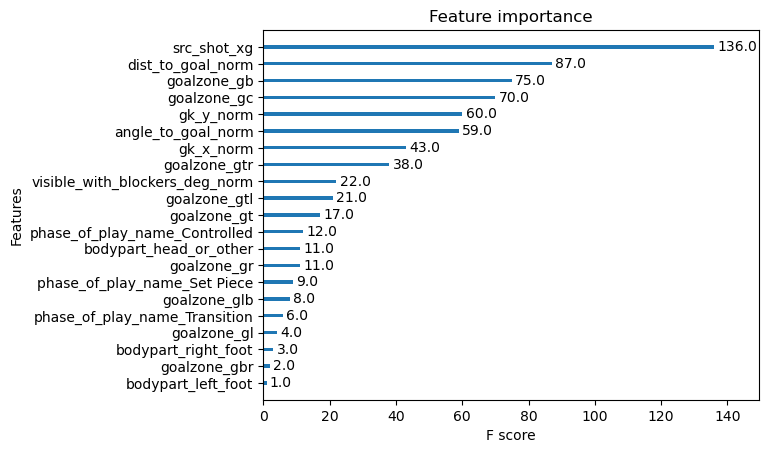

In [69]:
xgb.plot_importance(
    model,
    importance_type="weight",
    title="Feature importance",
    xlabel="F score",
    ylabel="Features",
    grid=False,
)
plt.show()

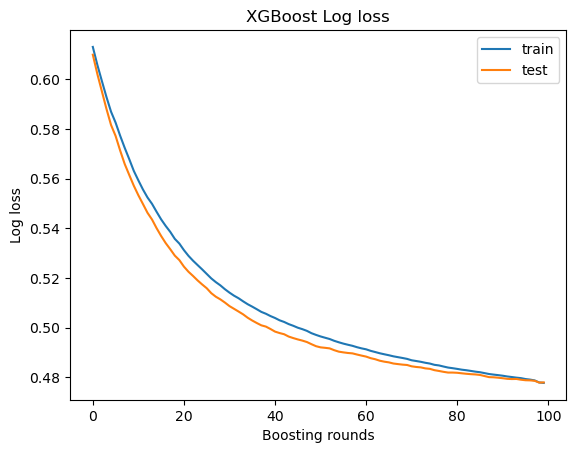

In [70]:
results = model.evals_result()
# plot the results
plt.plot(results["validation_0"]["logloss"], label="train")
plt.plot(results["validation_1"]["logloss"], label="test")
plt.xlabel("Boosting rounds")
plt.ylabel("Log loss")
plt.legend()
plt.title("XGBoost Log loss")
plt.show()